In [1]:
from pathlib import Path

dataset_root = Path("/kaggle/input/wildlife-aerial-images-from-drone")

yaml_text = f"""
path: {dataset_root}
train: images/train
val: images/valid
test: images/test

# Đọc classes.txt và tự sinh tên lớp
names:
"""

classes = (dataset_root / "classes.txt").read_text().strip().splitlines()
yaml_text += "\n".join([f"  {i}: {c}" for i, c in enumerate(classes)])

Path("waid.yaml").write_text(yaml_text)
print("✅ waid.yaml created:\n", yaml_text)

✅ waid.yaml created:
 
path: /kaggle/input/wildlife-aerial-images-from-drone
train: images/train
val: images/valid
test: images/test

# Đọc classes.txt và tự sinh tên lớp
names:
  0: sheep
  1: cattle
  2: seal
  3: camelus
  4: kiang
  5: zebra


In [2]:
!pip install -U ultralytics --no-deps

from ultralytics import YOLO
import os, subprocess, re

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import cv2, glob, os, numpy as np, pathlib

def is_bad_image(p):
    try:
        with open(p, "rb") as f:
            data = f.read()
        if not data:
            return "zero-byte"
        arr = np.frombuffer(data, np.uint8)
        im  = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        if im is None:
            return "decode-fail"
        return ""
    except Exception as e:
        return f"exception:{e}"

root = pathlib.Path(".")  # hoặc đặt = dataset_root nếu cần
splits = ["train","valid","test"]
bad = []
for sp in splits:
    for p in glob.glob(f"images/{sp}/**/*", recursive=True):
        if os.path.isdir(p): 
            continue
        ext = os.path.splitext(p)[1].lower()
        if ext not in [".jpg",".jpeg",".png",".bmp",".tif",".tiff",".webp"]:
            continue
        reason = is_bad_image(p)
        if reason:
            bad.append((p, reason))

print("Bad images:", len(bad))
for p, r in bad[:50]:
    print(" -", r, "->", p)


Bad images: 0


In [4]:
import os, glob, pathlib
miss_img, miss_lbl = [], []
for sp in ["train","valid","test"]:
    imgs = {pathlib.Path(p).stem for p in glob.glob(f"images/{sp}/*.*")}
    lbls = {pathlib.Path(p).stem for p in glob.glob(f"labels/{sp}/*.txt")}
    miss_img += [f"{sp}:{x}" for x in sorted(lbls - imgs)]
    miss_lbl += [f"{sp}:{x}" for x in sorted(imgs - lbls)]
print("Labels trỏ không có ảnh:", len(miss_img))
print(miss_img[:30])
print("Ảnh không có nhãn:", len(miss_lbl))
print(miss_lbl[:30])


Labels trỏ không có ảnh: 0
[]
Ảnh không có nhãn: 0
[]


In [5]:
import cv2, numpy as np
from ultralytics.utils import patches

def safe_imread(path, flags=cv2.IMREAD_COLOR):
    with open(path, "rb") as f:
        b = f.read()
    arr = np.frombuffer(b, np.uint8)     # 👈 chuyển bytes -> np.uint8
    img = cv2.imdecode(arr, flags)
    return img

patches.imread = safe_imread
print("✅ Patched ultralytics.utils.patches.imread")


✅ Patched ultralytics.utils.patches.imread


In [6]:
!nvidia-smi

import torch, platform
print("cuda_available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device_name:", torch.cuda.get_device_name(0))
print("torch:", torch.__version__, "| python:", platform.python_version())

Sun Nov 16 15:26:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       1MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
import numpy as np, cv2, sys
print("numpy module? ", type(np))
print("numpy file    ", getattr(np, "__file__", None))
print("cv2 version   ", cv2.__version__)

path = "/kaggle/input/wildlife-aerial-images-from-drone/images/test/0cba95f9-b89e-4034-8543-86276b057dae_jpg.rf.c8e47f70d213aae466cf3a59fcfd6c0b.jpg"
img = cv2.imread(path)
print("imread is None?", img is None)
print("type(img)      ", type(img))

# so sánh với numpy “sạch”
import importlib
_np = importlib.import_module("numpy")
print("is ndarray?    ", isinstance(img, _np.ndarray))

numpy module?  <class 'module'>
numpy file     /usr/local/lib/python3.11/dist-packages/numpy/__init__.py
cv2 version    4.12.0
imread is None? False
type(img)       <class 'numpy.ndarray'>
is ndarray?     True


In [8]:
from ultralytics import YOLO
import os, sys

# 🧠 load model
model = YOLO("yolo12s.pt")  # hoặc model_ckpt

# 🚀 train
results = model.train(
    data="waid.yaml",      # nhớ trỏ path về /kaggle/working/... để ghi cache
    imgsz=640,
    batch=0.9,               # hoặc -1 (auto ~60% VRAM) theo docs
    nbs=64,                # nominal batch size để tích luỹ/chuẩn hoá
    amp=True,              # nếu từng lỗi AMP -> False
    cache="disk",          # tránh /kaggle/input (read-only)
    workers=2,
    device=0,
    plots=False,
    save_period=-1,
    patience=30,
    epochs = 120
)

Ultralytics 8.3.228 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=0.9, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=waid.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=30, perspective=0.0, plots=False, pose=12.0, pretrained=True,

In [9]:
import pandas as pd
from pathlib import Path

# Đường dẫn thư mục run YOLO – chỉnh lại cho đúng
RUN_DIR = Path("runs/detect/train")  # vd: runs/detect/train, hoặc runs/detect/exp120
RESULTS_CSV = RUN_DIR / "results.csv"

df = pd.read_csv(RESULTS_CSV)
print(df.head())
print(df.columns)

   epoch      time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1   339.605         1.59726         1.18950         1.15404   
1      2   681.558         1.51205         0.76808         1.08399   
2      3  1023.680         1.57678         0.83068         1.11562   
3      4  1363.780         1.59263         0.85429         1.13032   
4      5  1704.360         1.54260         0.79479         1.11153   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.79871            0.73392           0.81403   
1               0.85346            0.77500           0.84826   
2               0.65293            0.60210           0.63454   
3               0.76504            0.55553           0.63763   
4               0.80235            0.69397           0.75037   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.43179       1.56923       0.80557       1.21423  0.003324   
1              0.47317       1.43973  

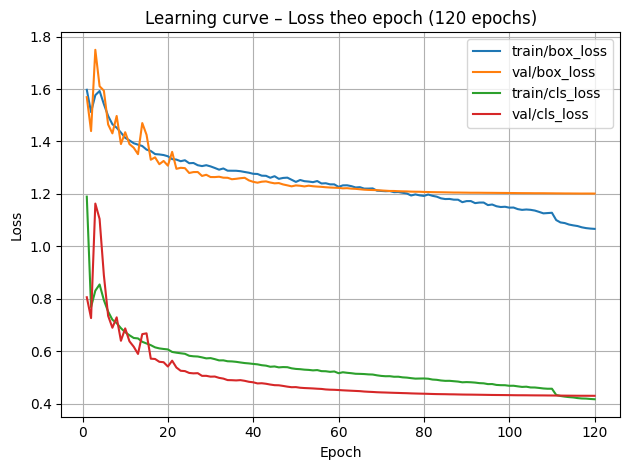

In [10]:
import matplotlib.pyplot as plt

epochs = df["epoch"]

plt.figure()
# Box loss
plt.plot(epochs, df["train/box_loss"], label="train/box_loss")
if "val/box_loss" in df.columns:
    plt.plot(epochs, df["val/box_loss"], label="val/box_loss")

# Class loss (nếu có)
if "train/cls_loss" in df.columns:
    plt.plot(epochs, df["train/cls_loss"], label="train/cls_loss")
if "val/cls_loss" in df.columns:
    plt.plot(epochs, df["val/cls_loss"], label="val/cls_loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning curve – Loss theo epoch (120 epochs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

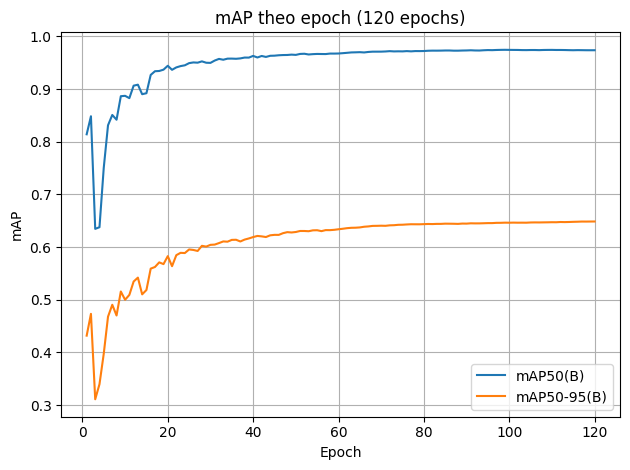

In [11]:
plt.figure()

if "metrics/mAP50(B)" in df.columns:
    plt.plot(epochs, df["metrics/mAP50(B)"], label="mAP50(B)")

if "metrics/mAP50-95(B)" in df.columns:
    plt.plot(epochs, df["metrics/mAP50-95(B)"], label="mAP50-95(B)")

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("mAP theo epoch (120 epochs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Best mAP50 = 0.9744 tại epoch 99


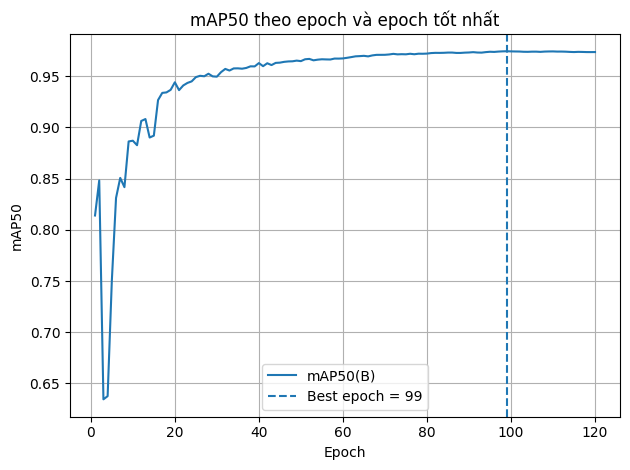

In [12]:
if "metrics/mAP50(B)" in df.columns:
    best_idx = df["metrics/mAP50(B)"].idxmax()
    best_epoch = int(df.loc[best_idx, "epoch"])
    best_map50 = float(df.loc[best_idx, "metrics/mAP50(B)"])

    print(f"Best mAP50 = {best_map50:.4f} tại epoch {best_epoch}")

    plt.figure()
    plt.plot(epochs, df["metrics/mAP50(B)"], label="mAP50(B)")
    plt.axvline(best_epoch, linestyle="--", label=f"Best epoch = {best_epoch}")
    plt.xlabel("Epoch")
    plt.ylabel("mAP50")
    plt.title("mAP50 theo epoch và epoch tốt nhất")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

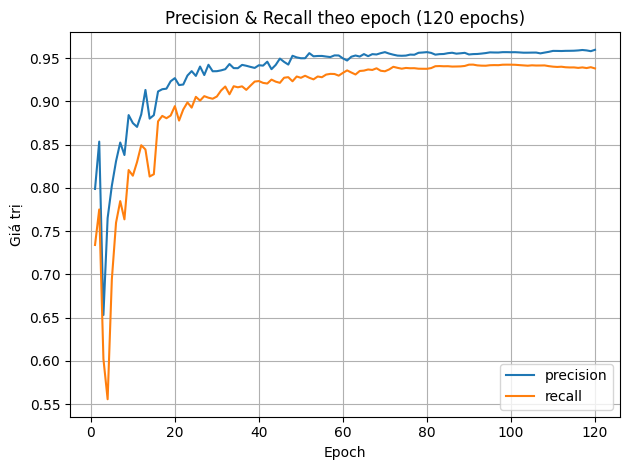

In [13]:
plt.figure()

if "metrics/precision(B)" in df.columns:
    plt.plot(epochs, df["metrics/precision(B)"], label="precision")

if "metrics/recall(B)" in df.columns:
    plt.plot(epochs, df["metrics/recall(B)"], label="recall")

plt.xlabel("Epoch")
plt.ylabel("Giá trị")
plt.title("Precision & Recall theo epoch (120 epochs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
# Chọn epoch có mAP50(B) cao nhất
best_idx = df["metrics/mAP50(B)"].idxmax()
best_row = df.loc[best_idx]

best_row

epoch                      99.000000
time                    33682.300000
train/box_loss              1.150920
train/cls_loss              0.469820
train/dfl_loss              0.974330
metrics/precision(B)        0.956880
metrics/recall(B)           0.942420
metrics/mAP50(B)            0.974420
metrics/mAP50-95(B)         0.646270
val/box_loss                1.203570
val/cls_loss                0.432170
val/dfl_loss                1.044700
lr/pg0                      0.001915
lr/pg1                      0.001915
lr/pg2                      0.001915
Name: 98, dtype: float64

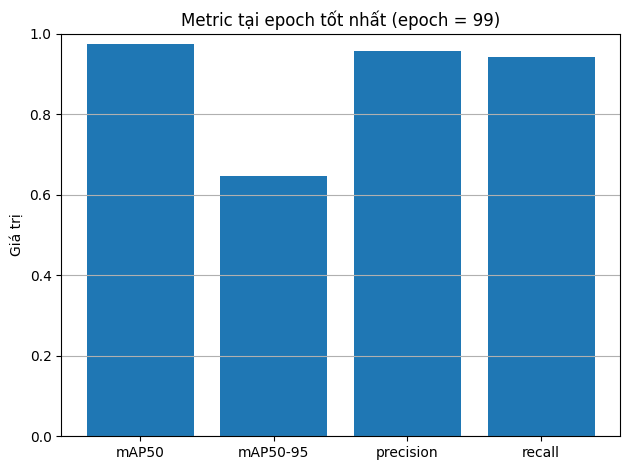

mAP50: 0.9744
mAP50-95: 0.6463
precision: 0.9569
recall: 0.9424


In [15]:
metrics = {}
metrics["mAP50"] = best_row["metrics/mAP50(B)"]
if "metrics/mAP50-95(B)" in df.columns:
    metrics["mAP50-95"] = best_row["metrics/mAP50-95(B)"]
if "metrics/precision(B)" in df.columns:
    metrics["precision"] = best_row["metrics/precision(B)"]
if "metrics/recall(B)" in df.columns:
    metrics["recall"] = best_row["metrics/recall(B)"]

plt.figure()
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0, 1.0)
plt.ylabel("Giá trị")
plt.title(f"Metric tại epoch tốt nhất (epoch = {int(best_row['epoch'])})")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")